# 7 영역처리
공간 영역의 처리는 대부분 마스크, 윈도우라고 불리는 커널을 이용해서 convolution(회선)을 수행함으로써 이루어진다. 여기서 회선에 대한 과정에 대한 명확한 이해가 없으면 적합한 필터링을 하고자 할 떄 적합한 마스크를 쉽게 구성하지 못할 수 있다.  
공간 영역의 개념과 공간 영역을 기반으로 처리할 수 있는 필터링에 대해서 기술한다. 또한 마스크 기반의 에지 검출 방법과 모폴로지에 대해서 설명한다.

# 7.1 회선 Convolution

## 7.1.1 공간 영역의 개념과 회선
### 영역의 의미
1. 두 개의 다른 범위의 구분
공간 영역과 주파수 영역의 구분이다. 여기서 공간 영역은 영상들이 다루어지는 화소 공간을 의미한다.

2. 영역 기반 처리
6장과 상반되는 의미로서 화소점 하나 하나의 개념이 아닌 화소가 모인 특정 범위의 화소 배열을 의미한다.
영역 기반 처리는 마스크라 불리는 규정된 영역을 기반으로 연산이 수행된다. 그래서 마스크 기반 처리라고도 불린다.

### 마스크 기반 처리
마스크 내의 원소값과 공간 영역에 있는 입력 영상의 화소값들을 대응되게 곱하여 출력 화소값을 계산하는 것을 말한다.
이런 처리를 모든 출력 화소 값에 대해 이동하면서 수행하는 것을 회선이라 한다.  

## 7.1.2 블러링
영상에서 화소값이 급격하게 변하는 부분들을 감소시켜 점진적으로 변하게 함으로써 영상이 전체적으로 부드러운 느낌이 나게 하는 기술이다.
커널 마스크의 모든 원소 값을 같게 구성하여 회선을 수행하면 블러링이 적용된다. 이때 전체 원소의 합이 1이 되어야 입력 영상의 밝기가 출력 영상에서 유지된다.
이 과정을 거치게 되면 출력 영상에서 이웃하는 화소들이 비슷한 값을 가지게 되어 점진적으로 변화하는 영상이 구성되고 따라서 출력 영상이 흐려진다.

In [3]:
import numpy as np, cv2
import matplotlib.pyplot as plt

In [3]:
def filter(img, mask):
    rows, cols = mask.shape[:2]
    dst = np.zeros((rows, cols), np.float32)
    ycent, xcent = rows//2, cols//2

    for i in range(ycent, rows - ycent):
        for j in range(xcent, cols - xcent):
            y1, y2 = i - ycent, i + ycent + 1
            x1, x2 = j - xcent, j + xcent + 1
            roi = img[y1:y2, x1:x2].astype('float32')
            tmp = cv2.multiply(roi, mask)
            dst[i, j] = cv2.sumElems(tmp)[0]

    return dst

def filter2(img, mask):
    rows, cols = img.shape[:2]
    dst = np.zeros((rows, cols), np.float32)
    ycent, xcent = rows, cols

    for i in range(1, ycent):
        for j in range(1, xcent):
            sum = 0.0
            for u in range(mask.shape[0]):
                for v in range(mask.shape[1]):
                    y, x = i + u - ycent, j + v - xcent
                    sum += img[y, x] * mask[u, v]
            dst[i, j] = sum

    return dst

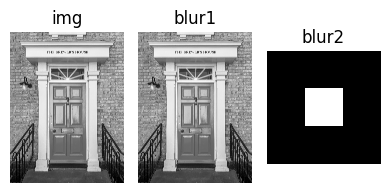

In [6]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

data = [
    1/9, 1/9, 1/9, 
    1/9, 1/9, 1/9, 
    1/9, 1/9, 1/9
]
mask = np.array(data, np.float32).reshape(3,3)
# blur1 = filter(img, mask)
# blur1 = blur1.astype('uint8')
blur2 = filter(img, mask)
	
blur1 = cv2.blur(img, (3,3))
blur2 = cv2.convertScaleAbs(blur2)

titles = ['img', 'blur1', 'blur2']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(4, 12))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4.1.3 사프닝
입력 화소에서 이웃 화소끼리 차이를 크게 되도록 출력 화소를 만들어서 날카로운 느낌이 나게 만드는 것이다. 이렇게 하면 영상의 세세한 부분을 강조할 수 있고 경계 부분에서 명암 대비가 증가되는 효과를 낼 수 있다.
그럼 어떻게 할까? 블러핑은 마스크의 원소를 모두 같게 했다면 반대로 차이가 커지도록 구성하면 된다. 
어떻게 커지게 만들 수 있을까? 마스크의 중심 위치의 계수를 중심 계수라 하는데 중심 비중이 크면 출력 영상은 입력 영상의 형태를 유지하고 주변계수와의 차이를 크게 만들면 샤프닝이 수행된다.
(영상 밝기와 마스크) 마스크 원소의 전체 합이 1이 되어야 입력 영상의 밝기가 손실 없이 출력 영상의 밝기로 유지된다. 그리고 1보다 작으면 출력 밝기가 어두어진다. 전체 합이 0이 되면 대부분의 출력 화소가 0이 되어 출력 영상이 검은색을 나타낸다(7.2장).
따라서 샤프닝에서는 중심계수는 1보다 크게(출력 밝기가 밝아진다.), 주변 계수는 비중을 감소 시킬 수 있도록 음수 값을 갖게 함, 전체 원소의 합은 1이 되도록 구성한다.

(ex)
[
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
] // 중심 계수는 5 > 1, 주변 계수는 음수 0, -1 , 전체 원소의 합은 1
[
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
] // 중심 계수는 9 > 1, 주변 계수는 음수 -1 , 전체 원소의 합은 1
[
    [1, -2, 1],
    [-2, 5, -2],
    [1, -2, 1]
] // 중심 계수는 5 > 1, 주변 계수는 음수 -1 , 전체 원소의 합은 1

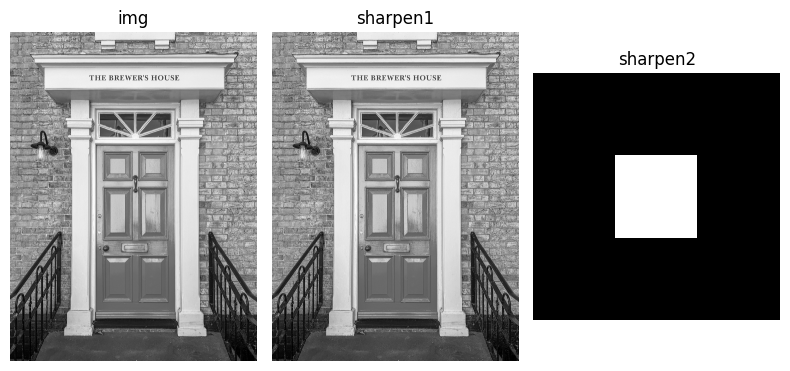

In [ ]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

data1 = [
    0, -1, 0,
    -1, 5, -1,
    0, -1, 0 ]
data2 = [
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
]
mask1 = np.array(data1, np.float32).reshape(3, 3)
mask2 = np.array(data2, np.float32)

	
sharpen1 = cv2.filter2D(img, -1, mask2, anchor=(-1, -1), delta=0, borderType=cv2.BORDER_DEFAULT)

sharpen2 = filter(img, mask2)
sharpen2 = cv2.convertScaleAbs(sharpen2)

titles = ['img', 'sharpen1', 'sharpen2']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 24))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 7.2 에지 검출
에지는 화소값이 급격하게 변화(높->낮, 낮->높)하는 부분이고 이는 어떤 물체의 윤곽선 혹은 경계선이며 이로서 크기, 위치 모양, 방향성을 알 수 있다.  
에지를 검출하는 방법은 이웃하는 화소의 차분이 특정 임계값 이상인 곳을 에지로 지정하거나 1,2차 미분 마스크를 이용하여 회선을 수행하는 것이다.  

## 7.2.1 1차 미분 마스크
에지의 정의에 의해서 F: (x, y) -> 화소값에 대한 함수에서 변화율을 취하면 에지를 검출 할 수 있다. 문제는 디지털 영상은 이산 데이터이므로 엄밀한 의미의 미분이 아닌 기울기를 구하는거에 가까운데  
어떤 마스크에서 중심에서 주변 계수와의 차이로 기울기로 알 수 있다 왜냐하면 분모의 차분은 사실 화소 단위여서 바뀔 수 있는 부분이지만 보통은 1이니까 그리고 수평 수직이라면 절대값을 구하는 것으로도 계산 복잡도를 줄일 수 있기도 하고 문제 없어 보인다. 그래서 예시로 x의 오른쪽 방향 미분을 알고 싶다면 1차 미분 마스크로서  [
    0, 0, 0
    0, 1, -1,
    0, 0, 0
] 이렇게 가지면 된다. 왜냐하면 마스크와 이미지를 회선을 수행할 때 서로 곱하면 차이가 되기 때문이다.  

1. 로버츠 마스크  
대각선 방향으로 1과 -1을 배치하여 구성한다. 한번만 차분을 진행하여 차분의 크기가 작고 이로 인해 경계가 확실한 에지만 추출하며 잡음에 매우 민감하다.

In [ ]:
def differential(img, data1, data2):
    mask1 = np.array(data1, np.float32).reshape(3, 3)
    mask2 = np.array(data2, np.float32).reshape(3, 3)

    dst1 = cv2.filter2D(img, cv2.CV_32F, mask1, anchor=(-1, -1), delta=0, borderType=cv2.BORDER_DEFAULT)
    dst2 = cv2.filter2D(img, cv2.CV_32F, mask2, anchor=(-1, -1), delta=0, borderType=cv2.BORDER_DEFAULT)
    dst1, dst2 = np.abs(dst1), np.abs(dst2)

    dst = cv2.magnitude(dst1, dst2) # root(g_x^2 + g_y^2)

    dst = np.clip(dst, 0, 255).astype('uint8')
    dst1 = np.clip(dst1, 0, 255).astype('uint8')
    dst2 = np.clip(dst2, 0, 255).astype('uint8')

    return dst, dst1, dst2

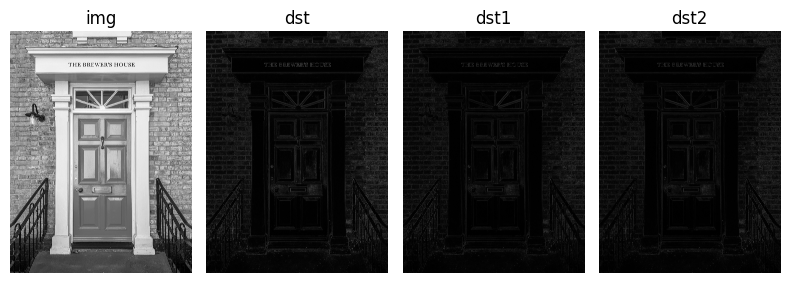

In [ ]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

data1 = [
    -1, 0, 0,
    0, 1, 0,
    0, 0, 0]

data2 = [
    0, 0, -1,
    0, 1, 0,
    0, 0, 0]

dst, dst1, dst2 = differential(img, data1, data2)

titles = ['img', 'dst', 'dst1', 'dst2']

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(8, 24))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

2. 프리윗 마스크
3번 계산을 통해서 로버츠 연산자에 비해 에지의 강도가 강하다

In [ ]:
def differential(img, data1, data2):
    mask1 = np.array(data1, np.float32).reshape(3, 3)
    mask2 = np.array(data2, np.float32).reshape(3, 3)

    dst1 = cv2.filter2D(img, cv2.CV_32F, mask1, anchor=(-1, -1), delta=0, borderType=cv2.BORDER_DEFAULT)
    dst2 = cv2.filter2D(img, cv2.CV_32F, mask2, anchor=(-1, -1), delta=0, borderType=cv2.BORDER_DEFAULT)
    
    dst = cv2.magnitude(dst1, dst2) # root(g_x^2 + g_y^2)

    dst = cv2.convertScaleAbs(dst)
    dst1 = cv2.convertScaleAbs(dst1)
    dst2 = cv2.convertScaleAbs(dst2)

    return dst, dst1, dst2

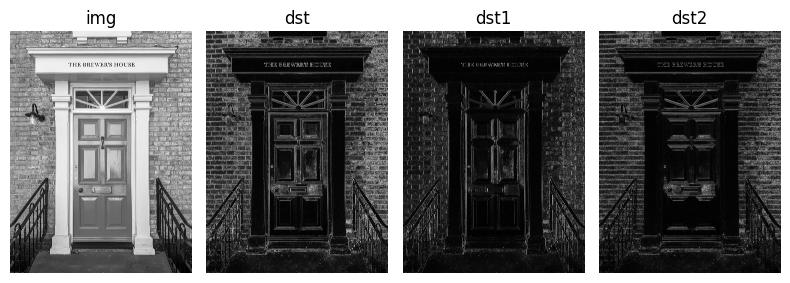

In [ ]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

data1 = [
    -1, 0, 1,
    -1, 0, 1,
    -1, 0, 1]

data2 = [
    -1, -1, -1,
    0, 0, 0,
    1, 1, 1]

dst, dst1, dst2 = differential(img, data1, data2)

titles = ['img', 'dst', 'dst1', 'dst2']

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(8, 24))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

3. 소벨(Sobel) 마스크
가장 대표적인 1차 미분 연산자이다. 프리윗 마스크와 유사하지만 중심계수의 차분에 대한 비중을 2배로 키웠다. 수직, 수평도 기존에도 잘 추출하였지만 중심계수의 차분 비중을 높여서 대각선 방향의 에지도 잘 검출된다.

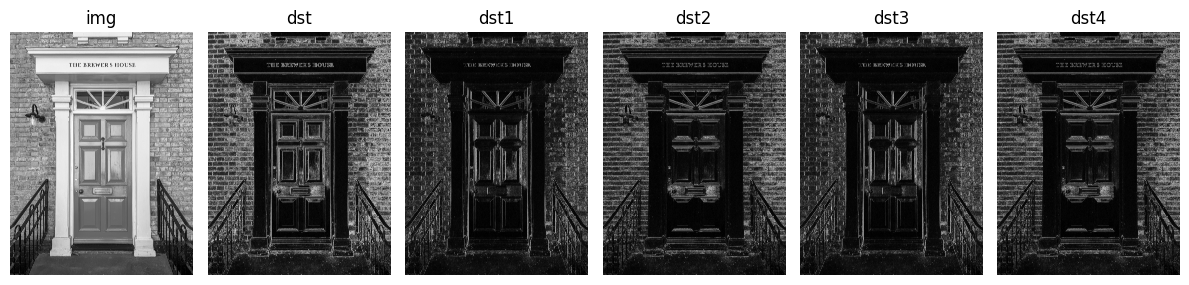

In [ ]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

data1 = [
    -1, 0, 1,
    -2, 0, 2,
    -1, 0, 1]

data2 = [
    -1, -2, -1,
    0, 0, 0,
    1, 2, 1]

dst, dst1, dst2 = differential(img, data1, data2)

dst3 = cv2.Sobel(np.float32(img), cv2.CV_32F, 1, 0, 3)
dst4 = cv2.Sobel(np.float32(img), cv2.CV_32F, 0, 1, 3)
dst3 = cv2.convertScaleAbs(dst3)
dst4 = cv2.convertScaleAbs(dst4)

titles = ['img', 'dst', 'dst1', 'dst2', 'dst3', 'dst4']

fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(12, 24))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 7.2.2 2차 미분 마스크
1차 미분 연산자는 밝기가 급격하게 변화하는 영역뿐만 아니라 점진적으로 변화하는 부분까지 민감하게 에지를 검출하여 너무 많은 에지가 나타날 수 있다. 그래서 여기서 한 번 더 미분연산을 하면 보완할 수 있다.
2차 미분 연산자는 변화하는 영역의 중심에 위치한 에지만 검출하고 밝기가 점진적으로 변화하는 영역에 대해서는 반응을 보이지 않는다.

1. 라플라시안 에지 검출
1차 미분한 결과를 한 번 더 미분하면 라플라시안 마스크 공식이 완성된다.

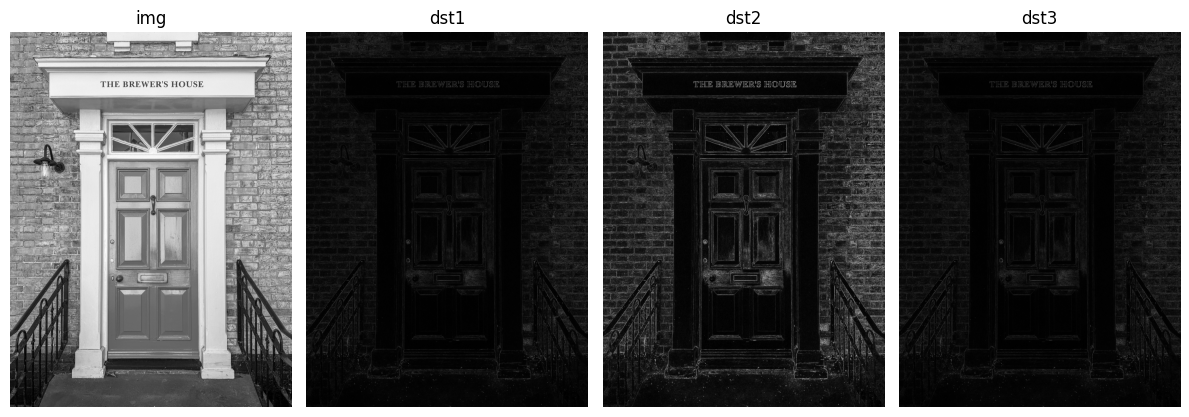

In [ ]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

data1 = [
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]]

data2 = [
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]]

mask4 = np.array(data1, np.int16)
mask8 = np.array(data2, np.int16)

dst1 = cv2.convertScaleAbs(cv2.filter2D(img, cv2.CV_16S, mask4))
dst2 = cv2.convertScaleAbs(cv2.filter2D(img, cv2.CV_16S, mask8))
dst3 = cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_16S, 1))



titles = ['img', 'dst1', 'dst2', 'dst3']

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(12, 24))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

2. LoG, DoG  
라플라시안은 잡음에 민감하다. 즉 미세한 노이즈마저 잡아낸다. 그래서 잡음을 먼저 제거하고 라플라시안을 수행하여 잡음에 강한 에지 검출이 가능하다 잡음은 미디언 필터링, 최댓값/최솟값 필터링 등을 수행할 수 있다. 그러나 이러한 필터링은 비 선형 공간 필터링이라 마스크 크기에 따라 속도 문제가 있다.  
그래서 속도를 생각하면 선형공간을 선택 하자.그래서 결론적으로 우리는 선형 공간 필터를 선택하여 회선을 하고 그 다음에 라플라시안 마스크로 회선을 하면 된다는 생각을 할 수 있고 이를 합쳐서 진행 할 수 있다. 이때 선형 공간 필터를 가우시안 스무딩 마스크를 선택하면 Laplacian of Gaussian LoG가 되는 것이다.  
하지만 LoG는 복잡한 공식에 의한 마스크 생성을 해야 해서 수행시간이 많이 걸린다. 그래서 단점을 보안하여 유사하면서 단순한 방법으로 구현하는 알고리즘을 Difference of Gaussian DoG이라 한다.  
LoG는 일단 정규분포함수를 그래디언트를 구한 것이라고 할 수 있다. 하지만 미분자체가 연산이 좀 들어가며 사실 정규분포함수의 그래디언트는 볼록하기(확인 필요함 볼록함 아니 오목할 수도 있음 아무튼 튀어 나왔다는 뜻이다.) 때문에 벡터장으로 보면 열의 방정식과 같은데 왜 같은가를 논하면 열은 주변으로 퍼진다. 근데 그 꼴이 그레디언트와 같은 것이다. 그래서 여기서 아이디어를 착안 해서 두 번 미분 한 것은 결국에는 분산이 변하는 속도(벡터)가 같기 때문에 두 사진의 가우시안의 차이와 같다는 것을 적용한 것이 DoG인 것이다. 그리고 LoG는 그런 볼록한 꼴이기에 그것을 어떤 행렬과 곱하면 차이를 알 수 있게 되는 것이다 그럼 왜 그렇냐를 생각해보면 마스크 원리 자체가 그걸 하게 해주는 것이다.  

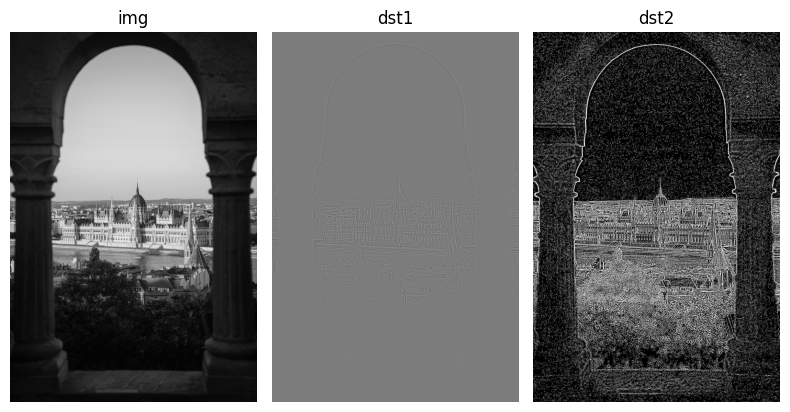

In [9]:
img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

gaus = cv2.GaussianBlur(img, (7, 7), 0, 0)
dst1 = cv2.Laplacian(gaus, cv2.CV_16S, 7)

gaus1 = cv2.GaussianBlur(img, (3, 3), 0, 0)
gaus2 = cv2.GaussianBlur(img, (9, 9), 0, 0)
dst2 = gaus1 - gaus2

titles = ['img', 'dst1', 'dst2']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 12))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7.2.3 캐니 에지 검출
영상 내에서 잡음은 다른 부분과 경계를 이루는 경우가 많다 그래서 잡음들을 에지로 검출하게 되고 이 문제를 해결하는 방법으로 캐니 에지 검출 기법이 있다. 다음은 캐니 알고리즘의 구성이다.  
1. 블러링을 통한 노이즈 제거 (가우시안 블러링)  
블러링은 5x5 크기의 가우시안 필터를 적용해서 수행한다. 하지만 블러링은 불필요한 잡음 제거를 위해 수행 하는 것이므로 마스크의 크기나 필터를 다르게 적용해도 된다.  
2. 화소 기울기(gradient)의 강도와 방향 검출 (소벨 마스크)  
소벨 마스크로 회선을 적용하고 그 결과를 이용해서 화소 기울기의 크기와 방향을 계산한다. 이때 방향은 4개 방향(0, 45, 90, 135)로 근사하여 단순화한다.  
3. 비최대치 억제(non-maximum suppression)  
현재 화소가 이웃하는 화소들보다 크면 에지를 보존하고, 그렇지 않으면 제거하는 것이다. 아까 4개 방향 일차원 벡터로 생각하면 0도는 idx = 3, 5, 45도는 idx = 0, 8, 90도는 idx = 1, 7, 135도는 idx = 2, 6의 중 최대치가 아닌 것은 억제 된다. 물론 이렇게 하여도 잘못된 에지로 결정되는 경우가 존재한다. 그래서 임계 값보다 작으면 에지에서 제거하는 방식으로 문제를 해결할 수 있다.   
4. 이력 임계값(hysteresis threshold)으로 에지 결정  
잘못된 에지를 제거하고 정확한 에지만을 검출하여 에지가 끊어지는 것을 방지하기 위해서 이 방식을 사용한다. 두 임계 값을 사용하여 두 임계값 T_max > T_min 이라고 하자 이때 T_max보다 크면 에지 추적을 시작하고 T_min 보다 큰 이웃 화소를 에지로 결정하는 방식이다.  

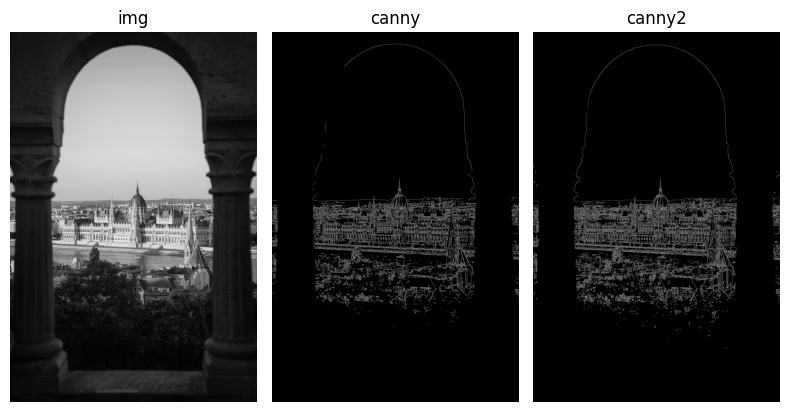

In [4]:
import sys
sys.setrecursionlimit(10**6)

def nonmax_suppression(sobel, direct):
    rows, cols = sobel.shape[:2]
    dst = np.zeros((rows, cols), np.float32)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            values = sobel[i - 1:i + 2, j - 1:j + 2].flatten()
            first = [3, 0, 1, 2]
            id = first[direct[i, j]]
            v1, v2 = values[id], values[8-id]

            dst[i, j] = sobel[i, j] if (v1 < sobel[i, j] > v2) else 0
    return dst

def trace(max_sobel, i, j, low):
    h, w = max_sobel.shape[:2]
    if not (0 <= i < h and 0 <= j < w): return
    
    if canny[i, j] == 255 or max_sobel[i, j] <= low:
        return

    canny[i, j] = 255
    
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0: continue
            trace(max_sobel, i + di, j + dj, low)

def hysteresis_th(max_sobel, low, high):
    rows, cols = max_sobel.shape[:2]
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if max_sobel[i, j] >= high: trace(max_sobel, i, j , low)

img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

pos_ck = np.zeros(img.shape[:2], np.uint8)
canny = np.zeros(img.shape[:2], np.uint8)

gaus_img = cv2.GaussianBlur(img, (5, 5), 0.3)
gx = cv2.Sobel(np.float32(gaus_img), cv2.CV_32F, 1, 0, 3)
gy = cv2.Sobel(np.float32(gaus_img), cv2.CV_32F, 0, 1, 3)
sobel = cv2.magnitude(gx, gy)

directs = cv2.phase(gx, gy) / (np.pi / 4)
directs = directs.astype(int) % 4
max_sobel = nonmax_suppression(sobel, directs)
hysteresis_th(max_sobel, 100, 150)

canny2 = cv2.Canny(img, 100, 150)

titles = ['img', 'canny', 'canny2']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 12))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()